# Comparison of ANN Variant Reconstructions

This notebook compares the four ANN variants with a consistent plotting style.

It produces four large figures, each arranged as a 2x2 panel grid:

- reconstructed $m_B(z)$
- inferred $D_A(z)$
- reconstructed $dm_B/dz$
- three-way $D_A(z)$ comparison against the old ANN result and a $\Lambda$CDM reference

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.1,
    'figure.dpi': 140,
})

project_dir = Path('/home/geng/Codes/sgl_cosmo/ann')
data_path = project_dir / 'data' / 'Pantheon+SH0ES.dat'
old_curve_path = project_dir / 'output' / 'old_ann' / 'rec_curve.npy'
comparison_dir = project_dir / 'output' / 'variant_comparison'
comparison_dir.mkdir(parents=True, exist_ok=True)

M_assumed = -19.3

variants = {
    'High alpha': {
        'result_dir': project_dir / 'output' / 'mb_ann_highalpha_run',
        'csv': 'pantheon_mb_ann_reconstruction.csv',
        'color': '#08519c',
    },
    'Inverse density weight': {
        'result_dir': project_dir / 'output' / 'mb_ann_inverse_density_run',
        'csv': 'pantheon_mb_ann_reconstruction.csv',
        'color': '#238b45',
    },
    'High-z CV score': {
        'result_dir': project_dir / 'output' / 'mb_ann_highz_score_run',
        'csv': 'pantheon_mb_ann_reconstruction.csv',
        'color': '#6a51a3',
    },
    'Bootstrap': {
        'result_dir': project_dir / 'output' / 'mb_ann_bootstrap_run',
        'csv': 'pantheon_mb_ann_bootstrap_reconstruction.csv',
        'color': '#d94801',
    },
}

pantheon = pd.read_csv(data_path, sep=r'\s+')
pantheon = pantheon.loc[pantheon['IS_CALIBRATOR'] == 0].copy()
pantheon['mu_from_mb'] = pantheon['m_b_corr'] - M_assumed
pantheon['dl_mpc'] = 10 ** ((pantheon['mu_from_mb'] - 25.0) / 5.0)
pantheon['da_mpc'] = pantheon['dl_mpc'] / (1.0 + pantheon['zHD']) ** 2

old_curve = np.load(old_curve_path)
old_z = old_curve[:, 0]
old_da = old_curve[:, 1]
old_da_sigma = old_curve[:, 2]

def load_variant_frame(result_dir, csv_name, m_assumed):
    recon = pd.read_csv(result_dir / csv_name)
    z = recon['z'].to_numpy()
    mb_mean = recon['m_b_mean'].to_numpy()
    mb_sigma = recon['m_b_sigma'].to_numpy()
    mu_mean = mb_mean - m_assumed
    dl_mean = 10 ** ((mu_mean - 25.0) / 5.0)
    dl_sigma = (np.log(10.0) / 5.0) * dl_mean * mb_sigma
    da_mean = dl_mean / (1.0 + z) ** 2
    da_sigma = dl_sigma / (1.0 + z) ** 2
    if 'dm_b_dz_mean' in recon.columns:
        dmb_dz = recon['dm_b_dz_mean'].to_numpy()
    else:
        dmb_dz = np.gradient(mb_mean, z)
    return {
        'table': recon,
        'z': z,
        'mb_mean': mb_mean,
        'mb_sigma': mb_sigma,
        'da_mean': da_mean,
        'da_sigma': da_sigma,
        'dmb_dz': dmb_dz,
    }

variant_results = {
    name: load_variant_frame(spec['result_dir'], spec['csv'], M_assumed)
    for name, spec in variants.items()
}

z_ref = next(iter(variant_results.values()))['z']
h0 = 67.74
omega_m = 0.308
omega_lambda = 1.0 - omega_m
c_km_s = 299792.458
e_z = np.sqrt(omega_m * (1.0 + z_ref) ** 3 + omega_lambda)
integrand = 1.0 / e_z
dz = np.diff(z_ref)
dc = np.empty_like(z_ref)
dc[0] = (c_km_s / h0) * z_ref[0] * integrand[0]
dc[1:] = (c_km_s / h0) * (
    dc[0] / (c_km_s / h0) + np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
)
lcdm_da = dc / (1.0 + z_ref)

def make_panel_figure(title):
    fig, axes = plt.subplots(2, 2, figsize=(12.4, 9.4), sharex=False)
    fig.suptitle(title, y=0.98, fontsize=16)
    return fig, axes.ravel()

panel_names = list(variants.keys())
print('Loaded variant runs:')
for name, spec in variants.items():
    print(f"- {name}: {spec['result_dir'] / spec['csv']}")
print(f'Assumed M_B = {M_assumed:.1f}')


Loaded variant runs:
- High alpha: /home/geng/Codes/sgl_cosmo/ann/output/mb_ann_highalpha_run/pantheon_mb_ann_reconstruction.csv
- Inverse density weight: /home/geng/Codes/sgl_cosmo/ann/output/mb_ann_inverse_density_run/pantheon_mb_ann_reconstruction.csv
- High-z CV score: /home/geng/Codes/sgl_cosmo/ann/output/mb_ann_highz_score_run/pantheon_mb_ann_reconstruction.csv
- Bootstrap: /home/geng/Codes/sgl_cosmo/ann/output/mb_ann_bootstrap_run/pantheon_mb_ann_bootstrap_reconstruction.csv
Assumed M_B = -19.3


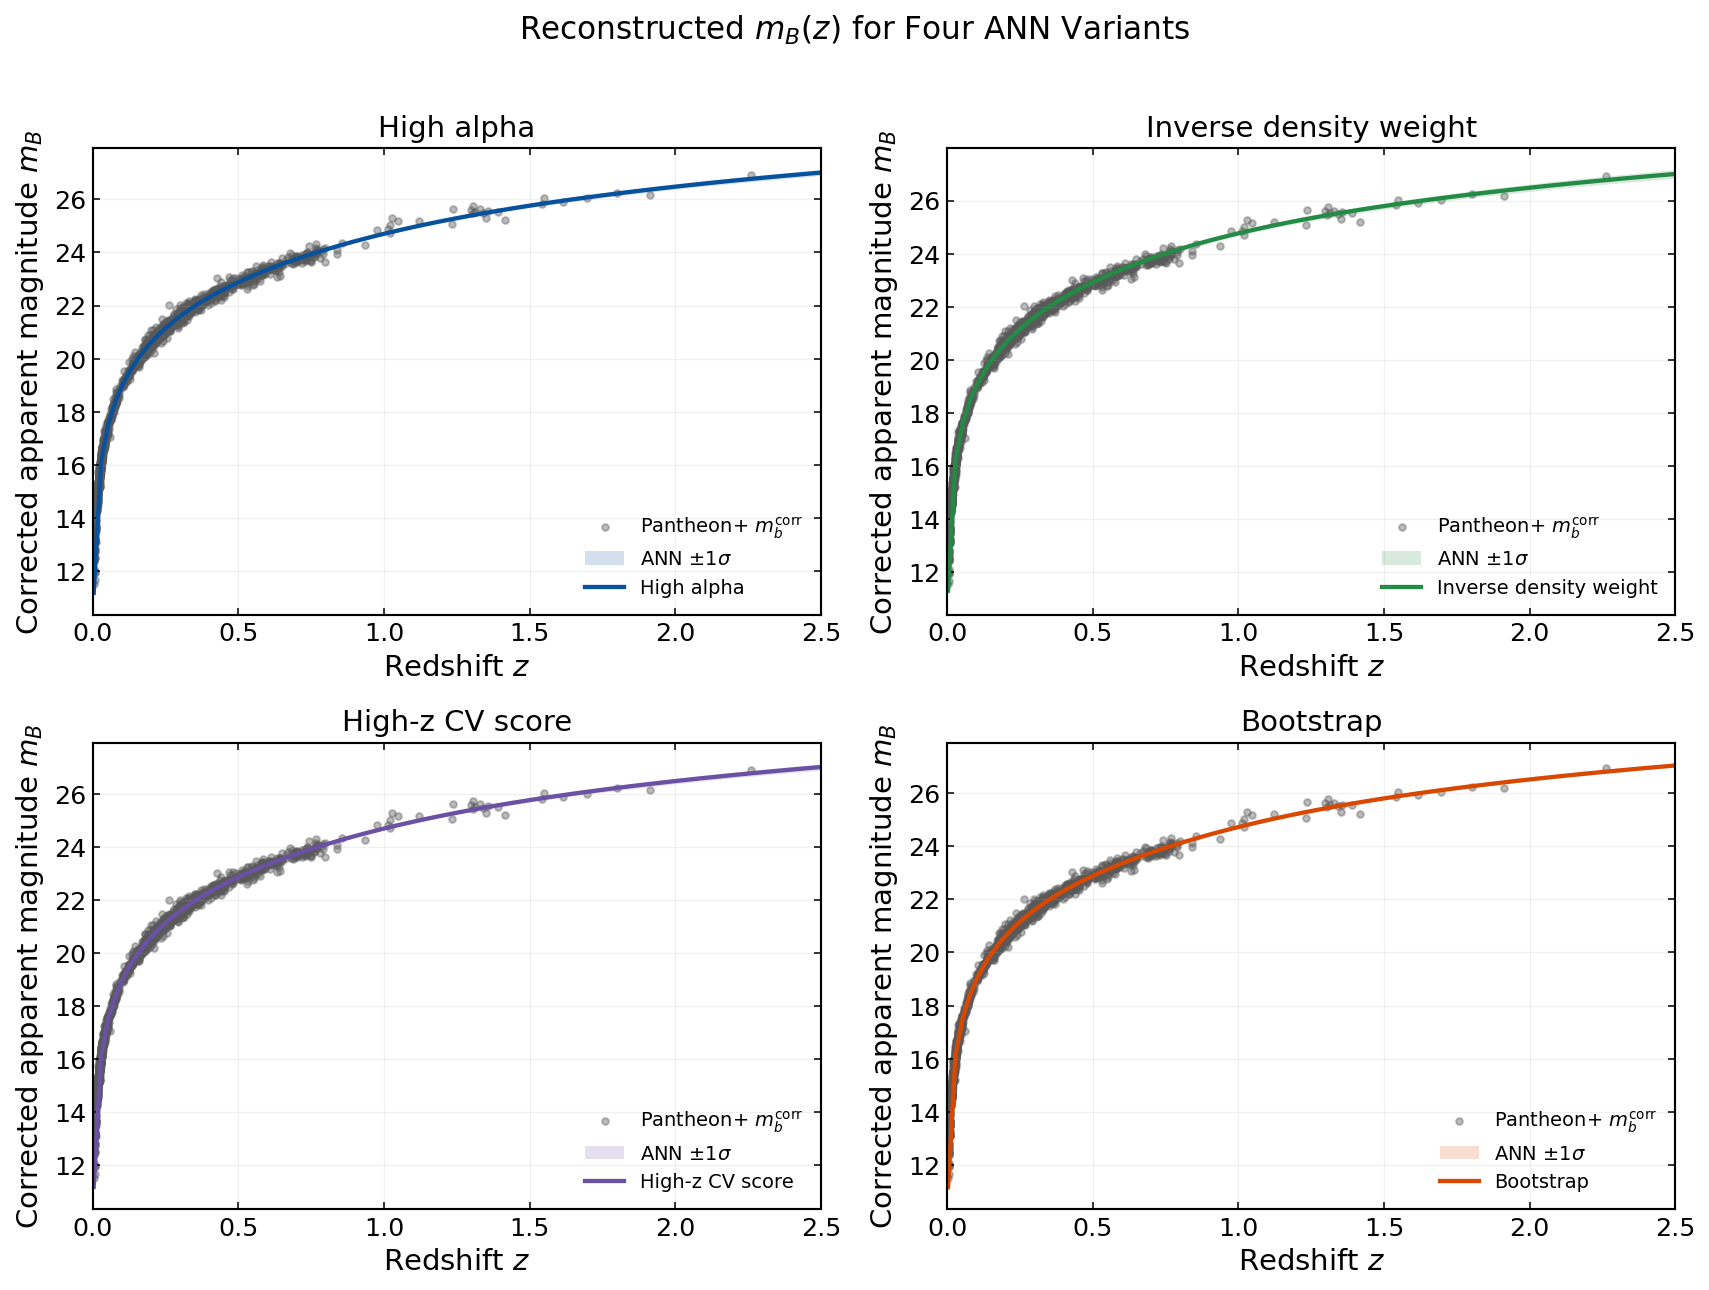

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_mb.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_mb.pdf


In [5]:
fig, axes = make_panel_figure(r'Reconstructed $m_B(z)$ for Four ANN Variants')

for ax, name in zip(axes, panel_names):
    spec = variants[name]
    result = variant_results[name]
    ax.scatter(
        pantheon['zHD'],
        pantheon['m_b_corr'],
        s=12,
        color='0.35',
        alpha=0.40,
        label='Pantheon+ $m_b^{\mathrm{corr}}$',
    )
    ax.fill_between(
        result['z'],
        result['mb_mean'] - result['mb_sigma'],
        result['mb_mean'] + result['mb_sigma'],
        color=spec['color'],
        alpha=0.18,
        linewidth=0.0,
        label=r'ANN $\pm 1\sigma$',
    )
    ax.plot(result['z'], result['mb_mean'], color=spec['color'], lw=2.2, label=name)
    ax.set_xlim(0.0, 2.5)
    ax.set_xlabel('Redshift $z$')
    ax.set_ylabel(r'Corrected apparent magnitude $m_B$')
    ax.set_title(name)
    ax.legend(frameon=False, loc='lower right')
    ax.grid(alpha=0.18, linewidth=0.6)

out_png = comparison_dir / 'variant_panels_mb.png'
out_pdf = comparison_dir / 'variant_panels_mb.pdf'
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


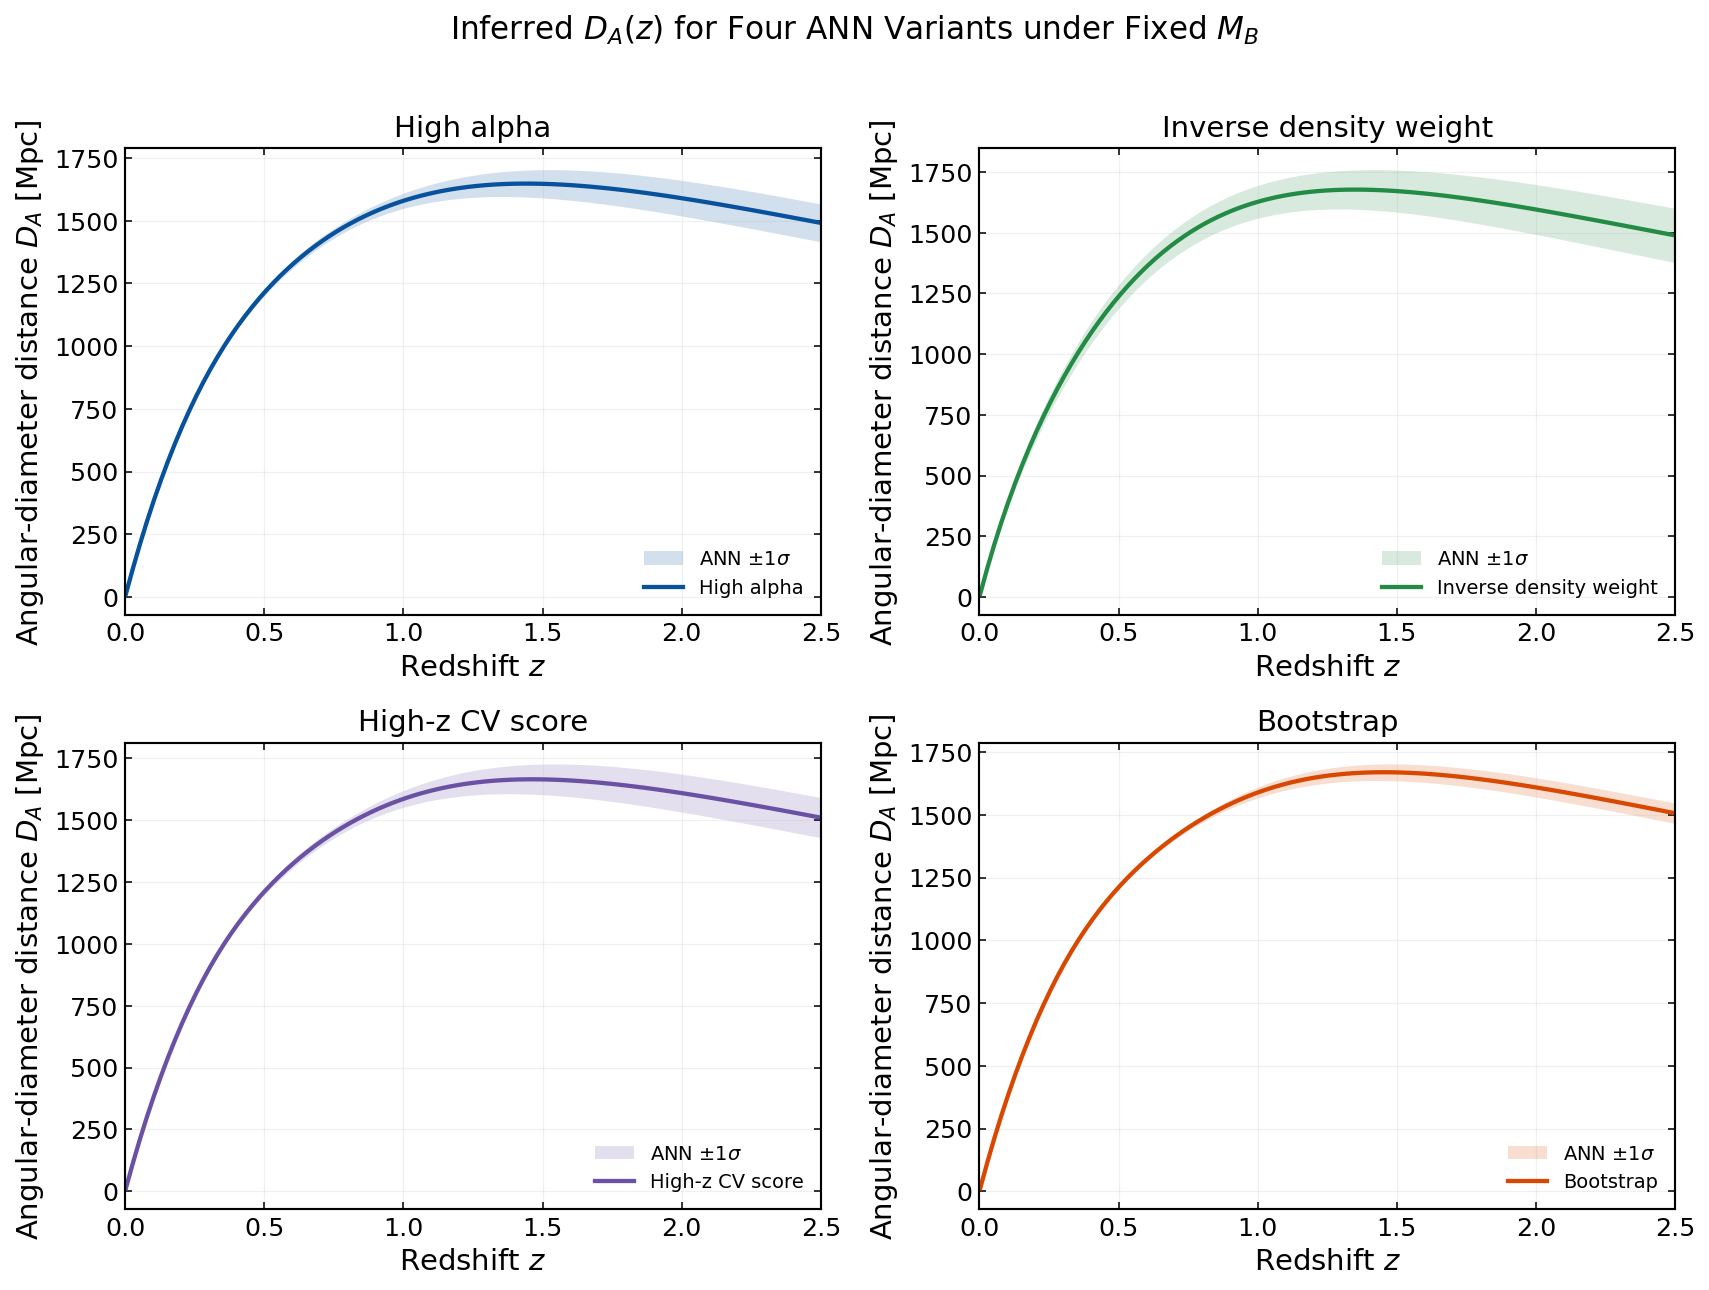

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_da.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_da.pdf


In [6]:
fig, axes = make_panel_figure(r'Inferred $D_A(z)$ for Four ANN Variants under Fixed $M_B$')

for ax, name in zip(axes, panel_names):
    spec = variants[name]
    result = variant_results[name]
    ax.fill_between(
        result['z'],
        result['da_mean'] - result['da_sigma'],
        result['da_mean'] + result['da_sigma'],
        color=spec['color'],
        alpha=0.18,
        linewidth=0.0,
        label=r'ANN $\pm 1\sigma$',
    )
    ax.plot(result['z'], result['da_mean'], color=spec['color'], lw=2.2, label=name)
    ax.set_xlim(0.0, 2.5)
    ax.set_xlabel('Redshift $z$')
    ax.set_ylabel(r'Angular-diameter distance $D_A$ [Mpc]')
    ax.set_title(name)
    ax.legend(frameon=False, loc='lower right')
    ax.grid(alpha=0.18, linewidth=0.6)

out_png = comparison_dir / 'variant_panels_da.png'
out_pdf = comparison_dir / 'variant_panels_da.pdf'
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


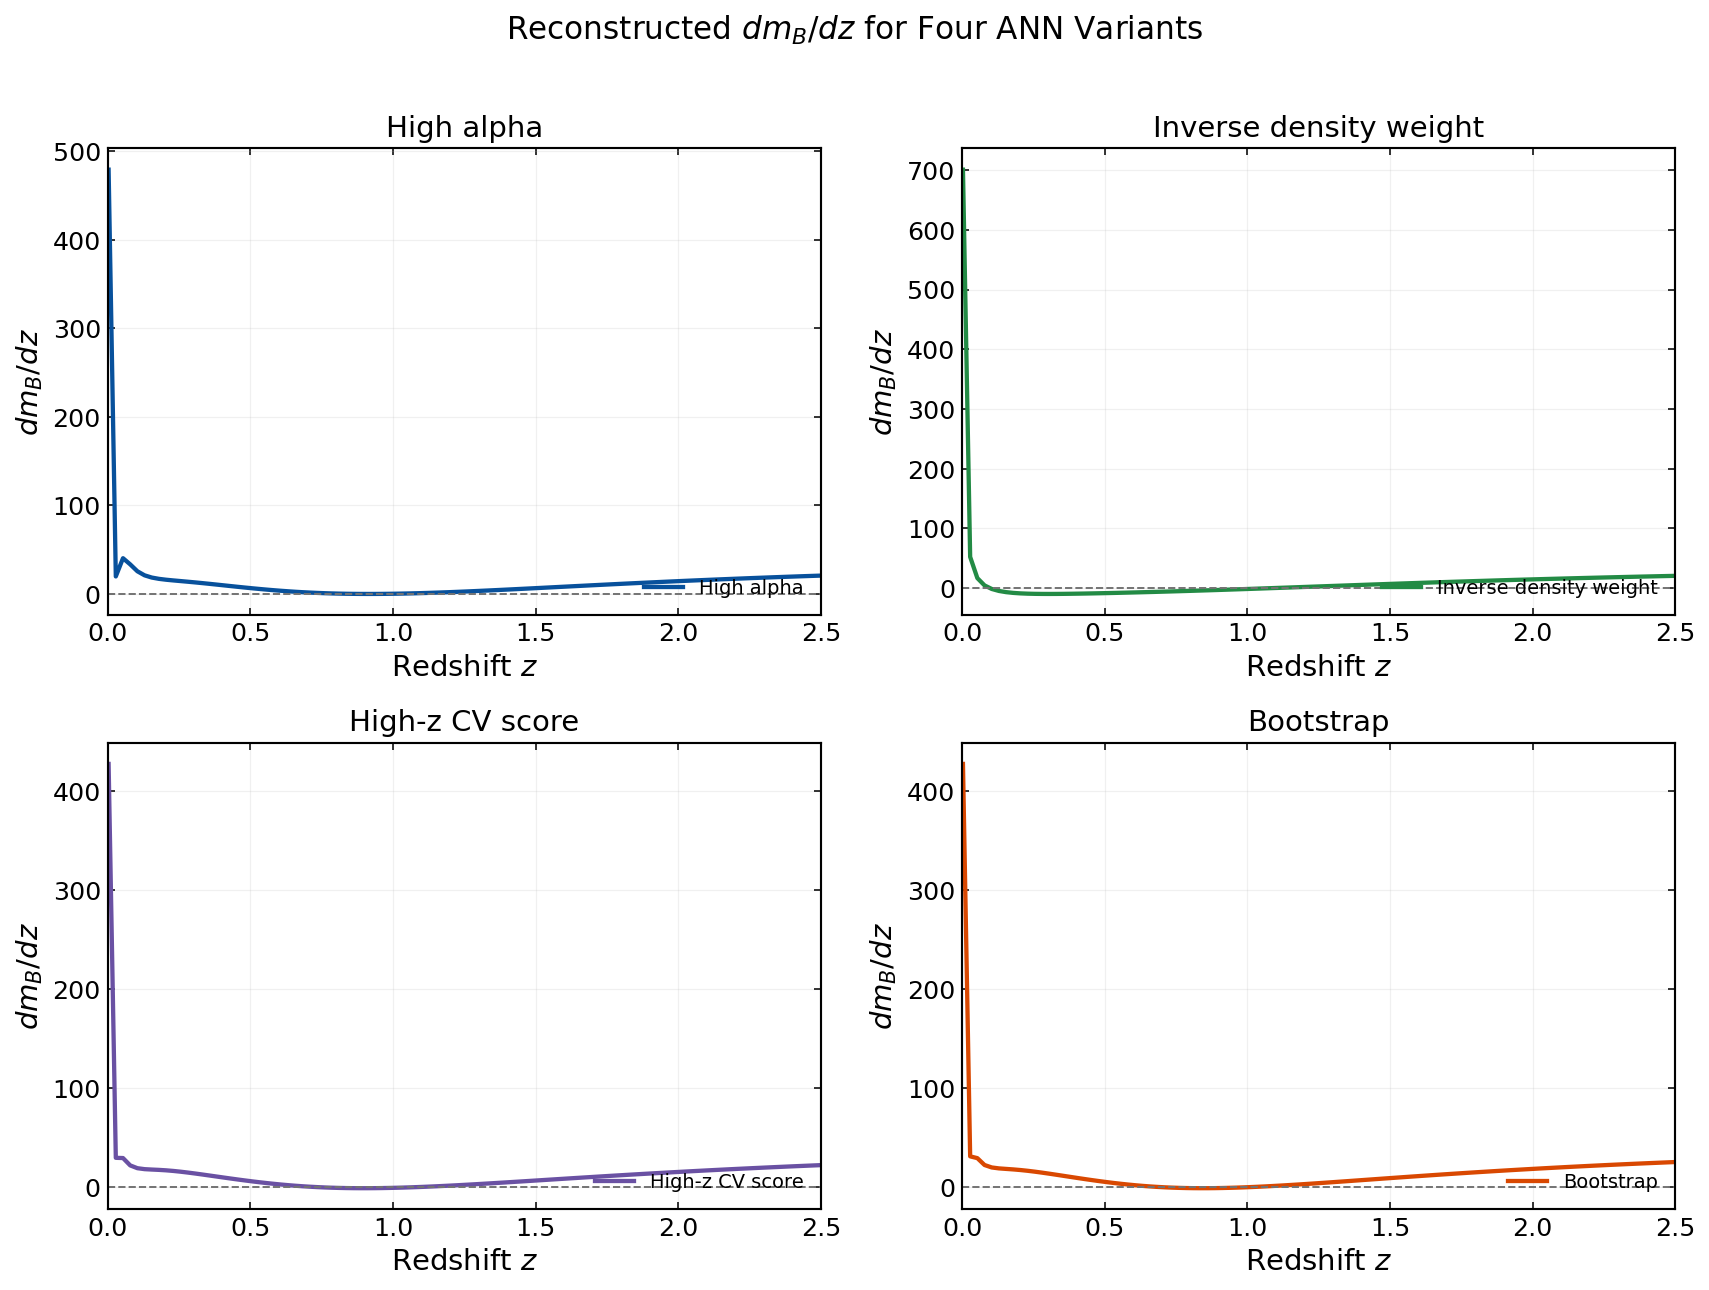

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_dmbdz.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_dmbdz.pdf


In [7]:
fig, axes = make_panel_figure(r'Reconstructed $dm_B/dz$ for Four ANN Variants')

for ax, name in zip(axes, panel_names):
    spec = variants[name]
    result = variant_results[name]
    ax.plot(result['z'], result['dmb_dz'], color=spec['color'], lw=2.2, label=name)
    ax.axhline(0.0, color='0.45', lw=1.0, ls='--')
    ax.set_xlim(0.0, 2.5)
    ax.set_xlabel('Redshift $z$')
    ax.set_ylabel(r'$dm_B/dz$')
    ax.set_title(name)
    ax.legend(frameon=False, loc='lower right')
    ax.grid(alpha=0.18, linewidth=0.6)

out_png = comparison_dir / 'variant_panels_dmbdz.png'
out_pdf = comparison_dir / 'variant_panels_dmbdz.pdf'
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


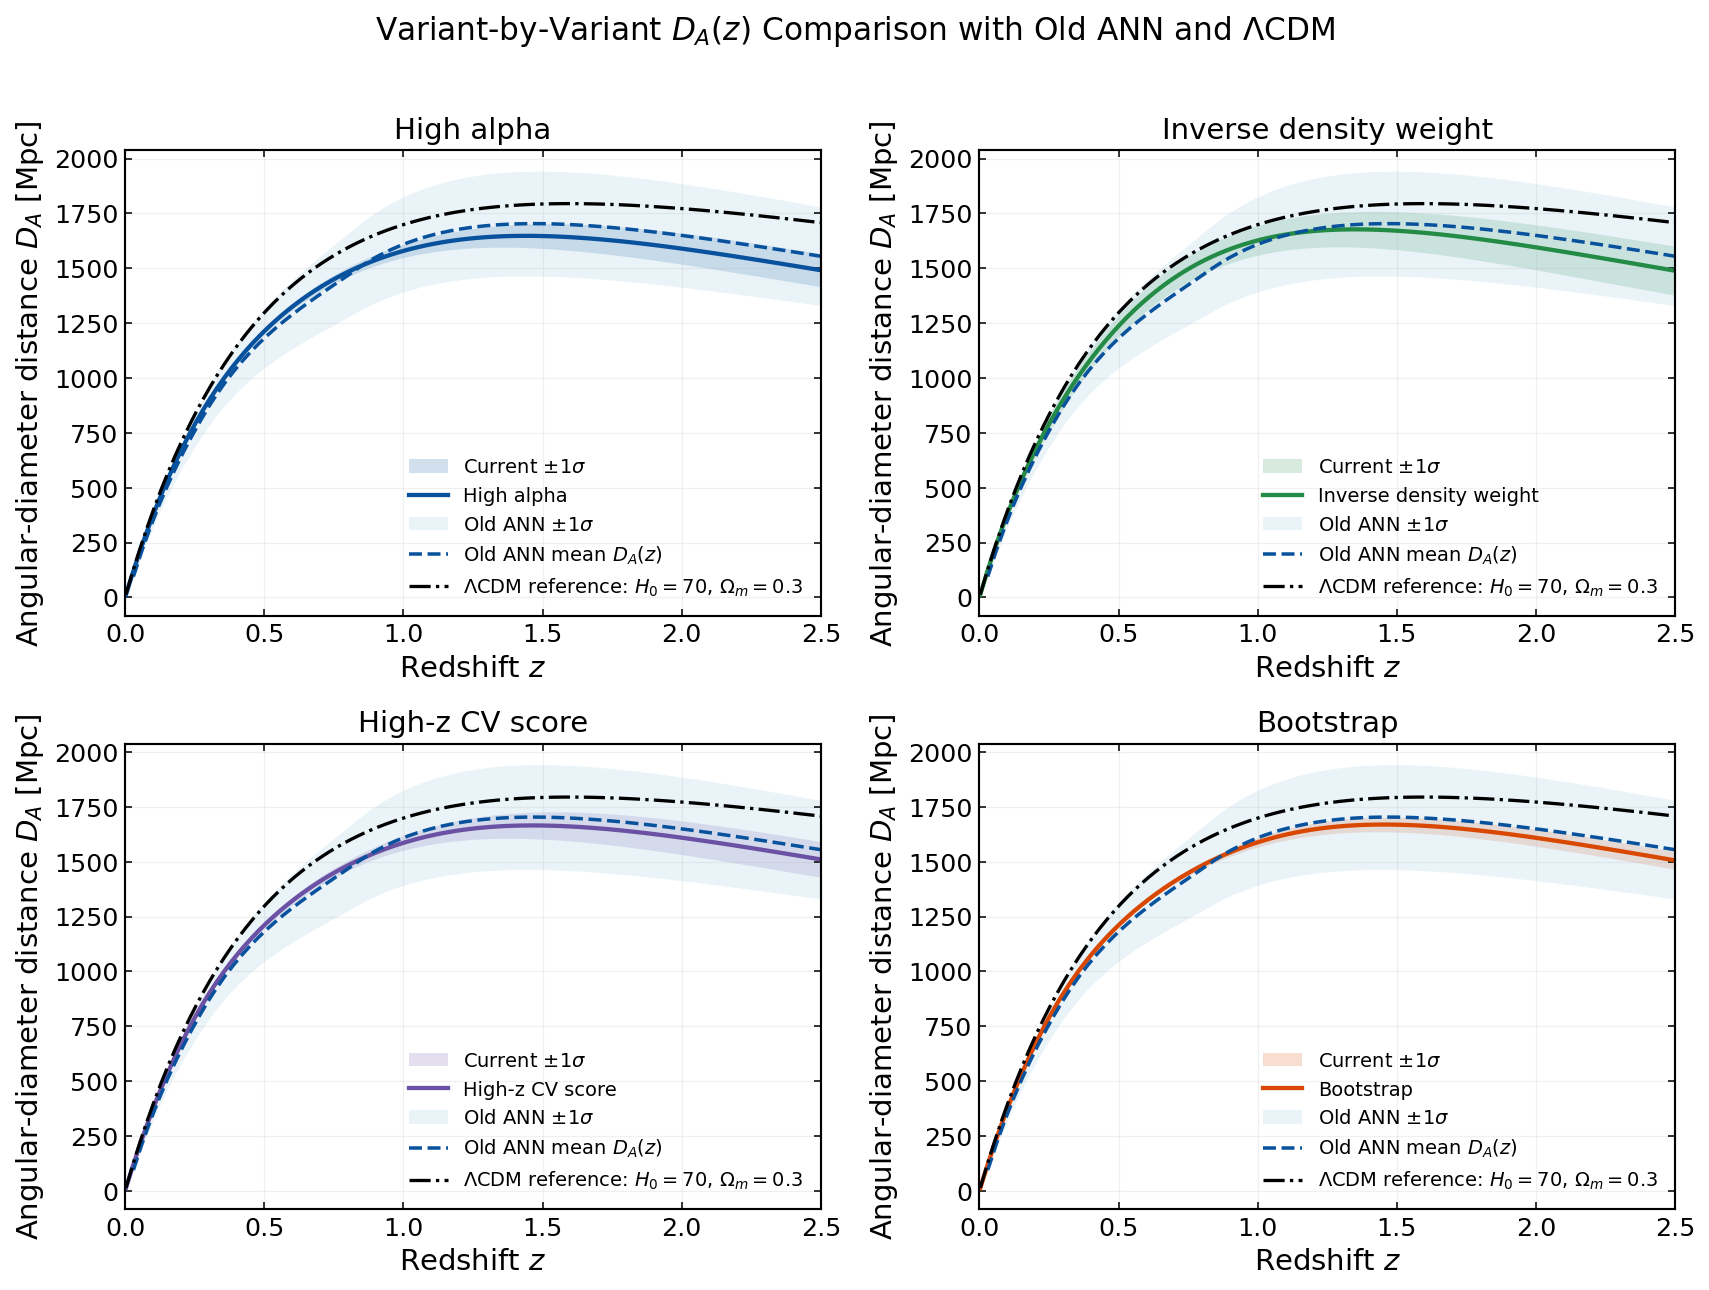

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_da_reference.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_panels_da_reference.pdf


In [9]:
fig, axes = make_panel_figure(r'Variant-by-Variant $D_A(z)$ Comparison with Old ANN and $\Lambda$CDM')

for ax, name in zip(axes, panel_names):
    spec = variants[name]
    result = variant_results[name]
    ax.fill_between(
        result['z'],
        result['da_mean'] - result['da_sigma'],
        result['da_mean'] + result['da_sigma'],
        color=spec['color'],
        alpha=0.18,
        linewidth=0.0,
        label=r'Current $\pm 1\sigma$',
    )
    ax.plot(result['z'], result['da_mean'], color=spec['color'], lw=2.2, label=name)
    ax.fill_between(
        old_z,
        old_da - old_da_sigma,
        old_da + old_da_sigma,
        color='#9ecae1',
        alpha=0.22,
        linewidth=0.0,
        label=r'Old ANN $\pm 1\sigma$',
    )
    ax.plot(old_z, old_da, color='#08519c', lw=1.8, ls='--', label=r'Old ANN mean $D_A(z)$')
    ax.plot(
        z_ref,
        lcdm_da,
        color='black',
        lw=1.7,
        ls='-.',
        label=r'$\Lambda$CDM reference: $H_0=70$, $\Omega_m=0.3$',
    )
    ax.set_xlim(0.0, 2.5)
    ax.set_xlabel('Redshift $z$')
    ax.set_ylabel(r'Angular-diameter distance $D_A$ [Mpc]')
    ax.set_title(name)
    ax.legend(frameon=False, loc='lower right')
    ax.grid(alpha=0.18, linewidth=0.6)

out_png = comparison_dir / 'variant_panels_da_reference.png'
out_pdf = comparison_dir / 'variant_panels_da_reference.pdf'
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


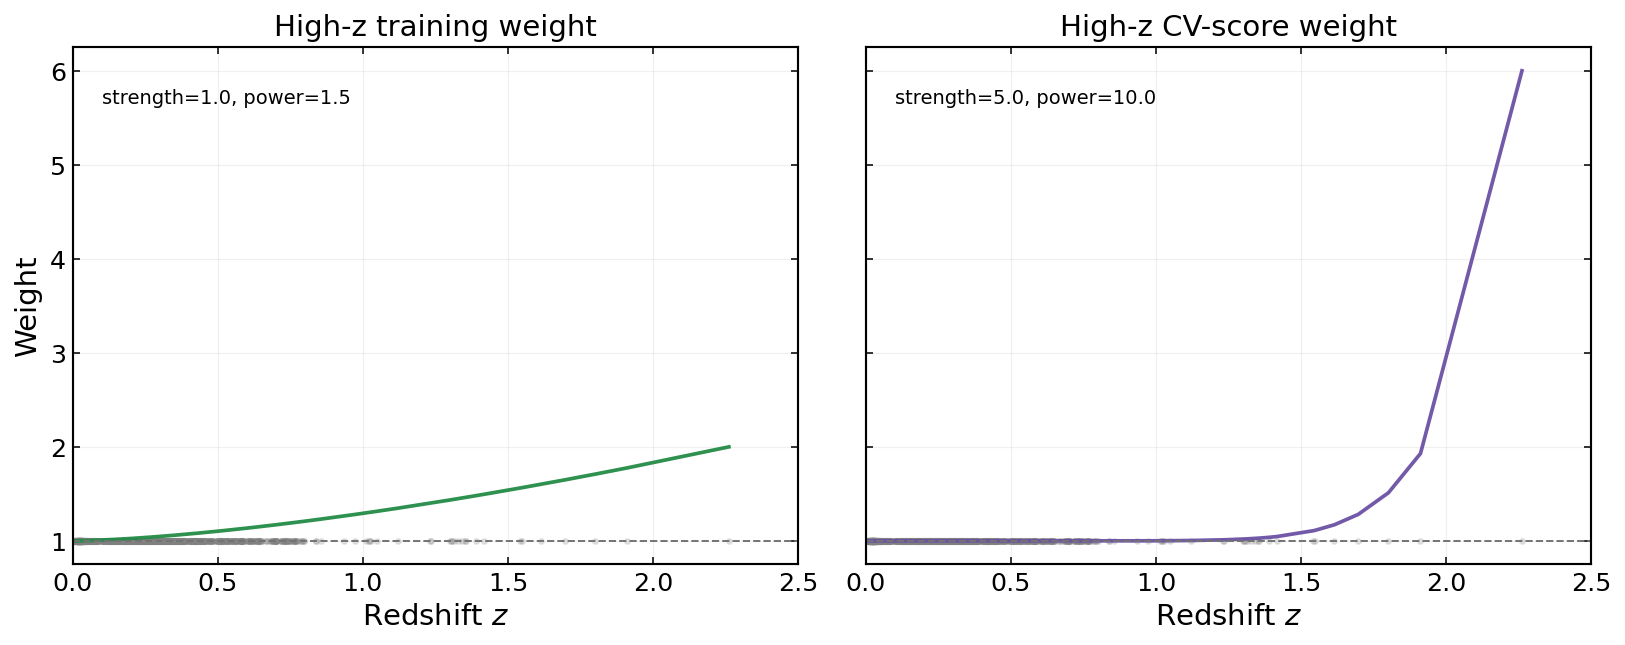

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_highz_weight_functions.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_highz_weight_functions.pdf


In [10]:
def highz_weight_function(z_values, strength=1.0, power=1.5):
    z_values = np.asarray(z_values, dtype=float)
    z_min = float(np.min(z_values))
    z_max = float(np.max(z_values))
    span = max(z_max - z_min, 1.0e-8)
    z_scaled = np.clip((z_values - z_min) / span, 0.0, 1.0)
    return 1.0 + strength * np.power(z_scaled, power)

z_weight_sample = np.sort(pantheon['zHD'].to_numpy())

highz_weight_strength = 1.0
highz_weight_power = 1.5
highz_score_strength = 5.0
highz_score_power = 10.0

train_weight = highz_weight_function(
    z_weight_sample,
    strength=highz_weight_strength,
    power=highz_weight_power,
)
score_weight = highz_weight_function(
    z_weight_sample,
    strength=highz_score_strength,
    power=highz_score_power,
)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8), sharey=True)

axes[0].plot(z_weight_sample, train_weight, color='#238b45', lw=1.9, alpha=0.95)
axes[0].scatter(z_weight_sample, np.full_like(z_weight_sample, 1.0), s=7, color='0.5', alpha=0.18, zorder=0)
axes[0].set_title('High-z training weight')
axes[0].set_xlabel('Redshift $z$')
axes[0].set_ylabel('Weight')
axes[0].grid(alpha=0.18, linewidth=0.6)
axes[0].text(
    0.04,
    0.92,
    f'strength={highz_weight_strength:.1f}, power={highz_weight_power:.1f}',
    transform=axes[0].transAxes,
    fontsize=10,
    va='top',
)

axes[1].plot(z_weight_sample, score_weight, color='#6a51a3', lw=1.9, alpha=0.95)
axes[1].scatter(z_weight_sample, np.full_like(z_weight_sample, 1.0), s=7, color='0.5', alpha=0.18, zorder=0)
axes[1].set_title('High-z CV-score weight')
axes[1].set_xlabel('Redshift $z$')
axes[1].grid(alpha=0.18, linewidth=0.6)
axes[1].text(
    0.04,
    0.92,
    f'strength={highz_score_strength:.1f}, power={highz_score_power:.1f}',
    transform=axes[1].transAxes,
    fontsize=10,
    va='top',
)

for ax in axes:
    ax.set_xlim(0.0, 2.5)
    ax.axhline(1.0, color='0.45', lw=1.0, ls='--')

out_png = comparison_dir / 'variant_highz_weight_functions.png'
out_pdf = comparison_dir / 'variant_highz_weight_functions.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


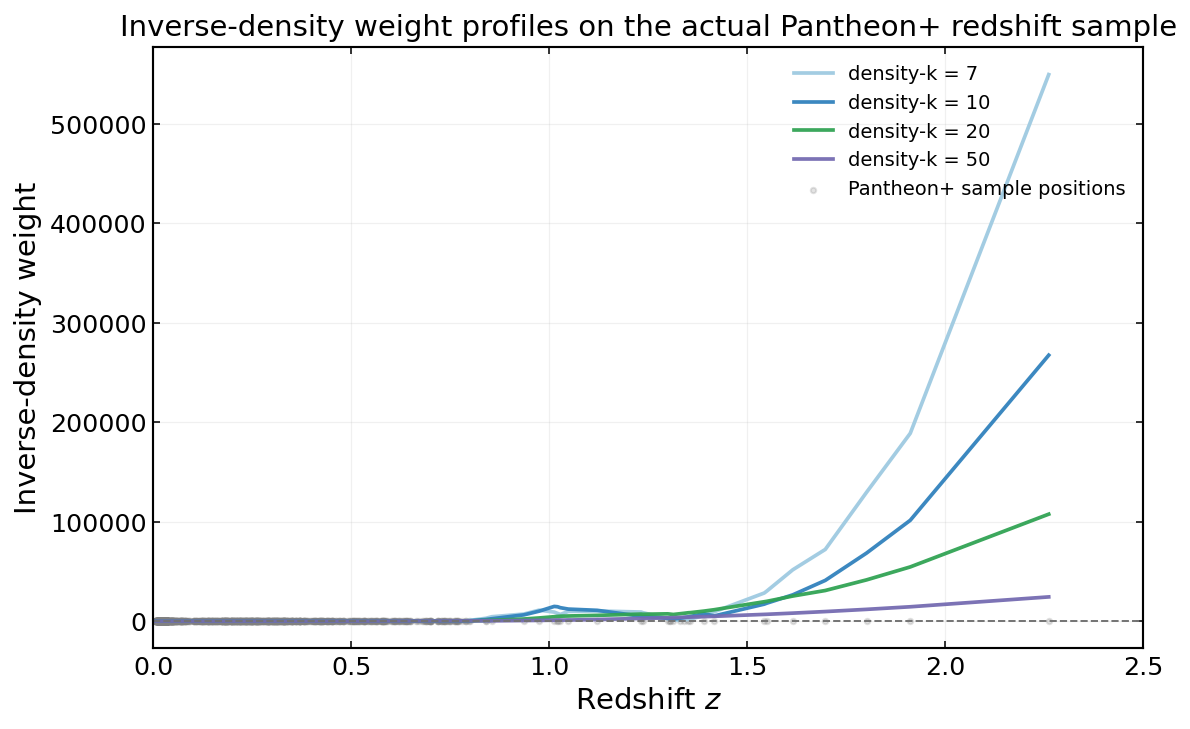

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_inverse_density_k_comparison.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/variant_inverse_density_k_comparison.pdf


In [12]:
def inverse_density_weight_function(z_values, strength=1.0, power=1.0, k=25, min_spacing=1.0e-3):
    z_values = np.asarray(z_values, dtype=float)
    order = np.argsort(z_values)
    z_sorted = z_values[order]
    z_unique, inverse, counts = np.unique(z_sorted, return_inverse=True, return_counts=True)

    if z_unique.size < 2:
        local_spacing_unique = np.full_like(z_unique, fill_value=min_spacing, dtype=float)
    else:
        k_index = min(max(int(k), 1), z_unique.size - 1)
        local_spacing_unique = np.empty_like(z_unique, dtype=float)
        for idx, z0 in enumerate(z_unique):
            distances = np.abs(z_unique - z0)
            local_spacing_unique[idx] = max(
                float(min_spacing),
                float(np.partition(distances, k_index)[k_index]),
            )

    spacing_sorted = local_spacing_unique[inverse]
    local_spacing = np.empty_like(spacing_sorted)
    local_spacing[order] = spacing_sorted

    reference_spacing = float(np.median(local_spacing))
    reference_spacing = max(reference_spacing, float(min_spacing))
    relative_sparsity = np.clip(local_spacing / reference_spacing, 1.0e-8, None)
    return 1.0 + strength * np.power(relative_sparsity, power)

z_density_sample = np.sort(pantheon['zHD'].to_numpy())
density_strength = 1.0
density_power = 2.0
density_ks = [7,10, 20, 50]
density_colors = ['#9ecae1', '#3182bd', '#31a354', '#756bb1']

fig, ax = plt.subplots(figsize=(8.6, 5.4))

for k_value, color in zip(density_ks, density_colors):
    density_weight = inverse_density_weight_function(
        z_density_sample,
        strength=density_strength,
        power=density_power,
        k=k_value,
    )
    ax.plot(z_density_sample, density_weight, color=color, lw=1.9, alpha=0.95, label=f'density-k = {k_value}')

ax.scatter(
    z_density_sample,
    np.full_like(z_density_sample, 1.0),
    s=8,
    color='0.5',
    alpha=0.22,
    label='Pantheon+ sample positions',
    zorder=0,
)
ax.axhline(1.0, color='0.45', lw=1.0, ls='--')
ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Inverse-density weight')
ax.set_title('Inverse-density weight profiles on the actual Pantheon+ redshift sample')
ax.legend(frameon=False, loc='upper right')
ax.grid(alpha=0.18, linewidth=0.6)

out_png = comparison_dir / 'variant_inverse_density_k_comparison.png'
out_pdf = comparison_dir / 'variant_inverse_density_k_comparison.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


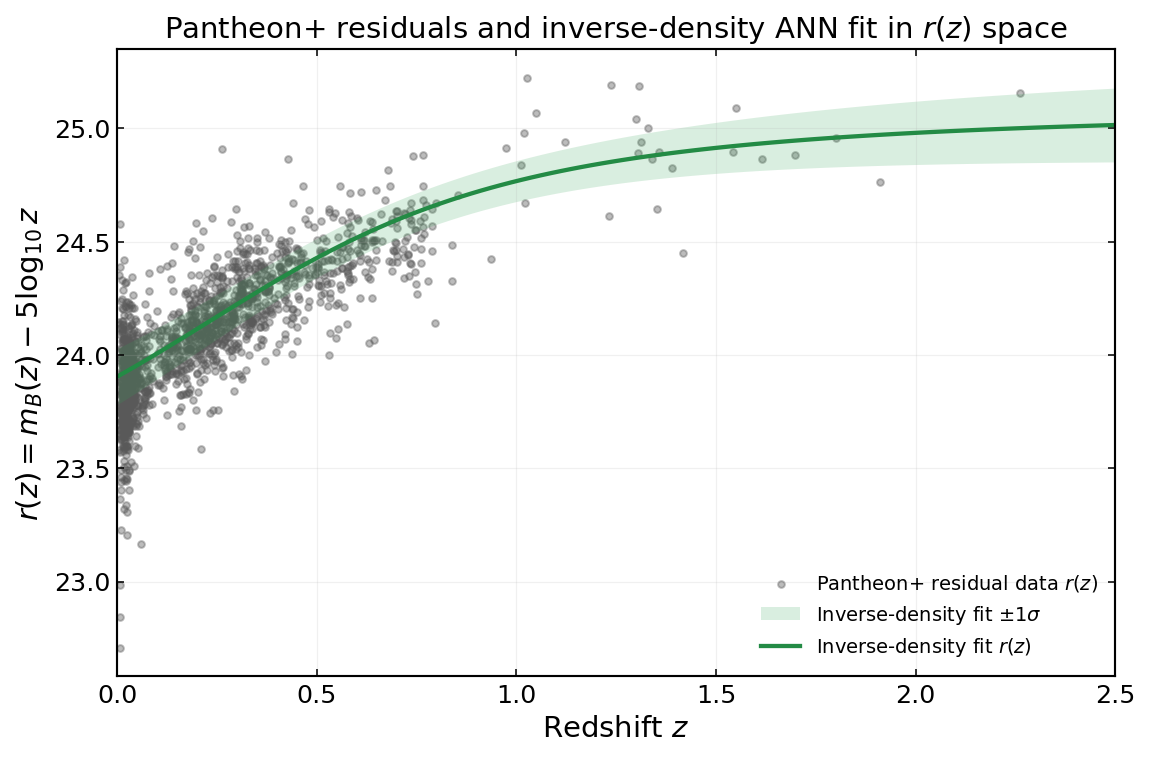

/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/inverse_density_residual_rz_comparison.png
/home/geng/Codes/sgl_cosmo/ann/output/variant_comparison/inverse_density_residual_rz_comparison.pdf


In [8]:
inverse_density_recon = variant_results['Inverse density weight']['table'].copy()

pantheon_r = pantheon.copy()
pantheon_r['r_of_z'] = pantheon_r['m_b_corr'] - 5.0 * np.log10(pantheon_r['zHD'].to_numpy())

inverse_density_recon['r_mean'] = (
    inverse_density_recon['m_b_mean'] - 5.0 * np.log10(inverse_density_recon['z'].to_numpy())
)

fig, ax = plt.subplots(figsize=(8.4, 5.6))

ax.scatter(
    pantheon_r['zHD'],
    pantheon_r['r_of_z'],
    s=12,
    color='0.35',
    alpha=0.40,
    label=r'Pantheon+ residual data $r(z)$',
)

ax.fill_between(
    inverse_density_recon['z'],
    inverse_density_recon['r_mean'] - inverse_density_recon['m_b_sigma'],
    inverse_density_recon['r_mean'] + inverse_density_recon['m_b_sigma'],
    color='#31a354',
    alpha=0.18,
    linewidth=0.0,
    label=r'Inverse-density fit $\pm 1\sigma$',
)
ax.plot(
    inverse_density_recon['z'],
    inverse_density_recon['r_mean'],
    color='#238b45',
    lw=2.2,
    label=r'Inverse-density fit $r(z)$',
)

ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$r(z) = m_B(z) - 5\log_{10} z$')
ax.set_title(r'Pantheon+ residuals and inverse-density ANN fit in $r(z)$ space')
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.18, linewidth=0.6)

out_png = comparison_dir / 'inverse_density_residual_rz_comparison.png'
out_pdf = comparison_dir / 'inverse_density_residual_rz_comparison.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)
